# Student Loan Default Analysis Report

In [33]:
#importing all the necessary libraries

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
#importing the dataset
df = pd.read_csv("student_loan_data.csv")

In [35]:
df.head()

,Student_ID,Country,Course_Duration_Years,GPA,Cosigner_Present,Loan_Amount,Annual_Income,Default_Status,Loan_Term_Years,Repayment_Status,Tuition_Cost,Loan_Disbursement_Date,Graduation_Date
0,1001,Canada,4,3.14,No,56224.51,NaN,Defaulted,15,No Payment,51294.48,2020-01-31,2024-05-31
1,1002,USA,2,NaN,Yes,40308.27,NaN,Not Defaulted,10,Delayed,36604.95,2020-02-29,2024-06-30
2,1003,USA,1,2.88,No,36542.10,4682.06,Not Defaulted,10,Delayed,55648.58,2020-03-31,2024-07-31
3,1004,USA,5,1.94,No,38050.77,26019.10,Defaulted,10,On Time,41722.54,2020-04-30,2024-08-31
4,1005,USA,4,3.09,No,35832.44,56597.49,Not Defaulted,5,No Payment,40541.32,2020-05-31,2024-09-30


In [36]:
df.describe()

,Student_ID,Course_Duration_Years,GPA,Loan_Amount,Annual_Income,Loan_Term_Years,Tuition_Cost
count,50.00000,50.000000,45.000000,45.000000,46.000000,50.000000,50.000000
mean,1025.50000,2.960000,2.985778,40326.653556,33119.266304,8.860000,47678.635400
std,14.57738,1.413636,0.516014,9752.500254,15693.986987,3.686766,10187.035682
min,1001.00000,1.000000,1.940000,18472.610000,4682.060000,5.000000,29935.900000
25%,1013.25000,2.000000,2.740000,35500.190000,21708.170000,5.000000,41005.572500
50%,1025.50000,3.000000,2.990000,40109.260000,31185.565000,8.500000,46082.405000
75%,1037.75000,4.000000,3.200000,45022.390000,45306.495000,10.000000,54206.797500
max,1050.00000,5.000000,4.260000,62398.660000,64639.340000,15.000000,75093.180000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              50 non-null     int64  
 1   Country                 50 non-null     object 
 2   Course_Duration_Years   50 non-null     int64  
 3   GPA                     45 non-null     float64
 4   Cosigner_Present        46 non-null     object 
 5   Loan_Amount             45 non-null     float64
 6   Annual_Income           46 non-null     float64
 7   Default_Status          50 non-null     object 
 8   Loan_Term_Years         50 non-null     int64  
 9   Repayment_Status        50 non-null     object 
 10  Tuition_Cost            50 non-null     float64
 11  Loan_Disbursement_Date  50 non-null     object 
 12  Graduation_Date         50 non-null     object 
dtypes: float64(4), int64(3), object(6)
memory usage: 5.2+ KB


# Data Cleansing /Data preprocessing

### Handling missing values

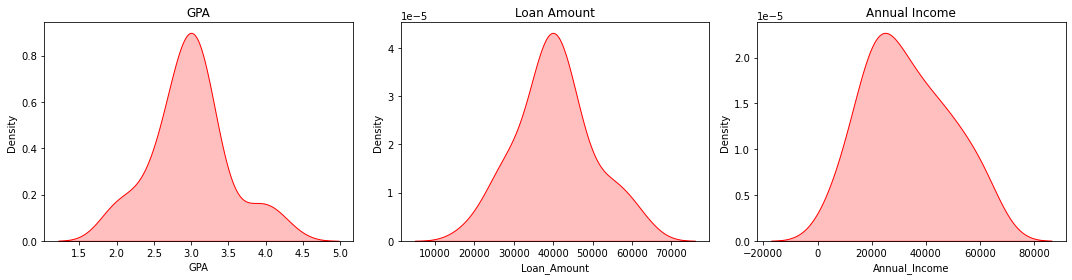

In [38]:

# Creating a new dataset
df1 = df[['GPA', 'Loan_Amount', 'Annual_Income']]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# Plotting GPA
sns.kdeplot(data=df1, x='GPA', ax=axes[0], fill=True, color='red')
axes[0].set_title('GPA')

# Plotting Loan Amount
sns.kdeplot(data=df1, x='Loan_Amount', ax=axes[1], fill=True, color='red')
axes[1].set_title('Loan Amount')

# Plotting Annual Income
sns.kdeplot(data=df1, x='Annual_Income', ax=axes[2], fill=True, color='red')
axes[2].set_title('Annual Income')

plt.tight_layout()  
plt.show()  


In [39]:
# replacing null values

df['GPA'].fillna(df['GPA'].median(),inplace = True)

df['Loan_Amount'].fillna(df['Loan_Amount'].median(),inplace = True)

df['Annual_Income'].fillna(df['Annual_Income'].mean(),inplace = True)

In [40]:
df['Cosigner_Present'].value_counts()

No     23
Yes    23
Name: Cosigner_Present, dtype: int64

In [41]:
np.random.seed(21)
df['Cosigner_Present'] = df['Cosigner_Present'].apply(
    lambda x: np.random.choice(df['Cosigner_Present'].dropna().unique()) if pd.isnull(x) else x)


In [42]:
df['Cosigner_Present'].value_counts()

No     25
Yes    25
Name: Cosigner_Present, dtype: int64

## Changing the data types

In [43]:
df['Student_ID'] = df['Student_ID'].astype('object')

df['Loan_Disbursement_Date'] = pd.to_datetime(df['Loan_Disbursement_Date'])

df['Graduation_Date'] = pd.to_datetime(df['Graduation_Date'])


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Student_ID              50 non-null     object        
 1   Country                 50 non-null     object        
 2   Course_Duration_Years   50 non-null     int64         
 3   GPA                     50 non-null     float64       
 4   Cosigner_Present        50 non-null     object        
 5   Loan_Amount             50 non-null     float64       
 6   Annual_Income           50 non-null     float64       
 7   Default_Status          50 non-null     object        
 8   Loan_Term_Years         50 non-null     int64         
 9   Repayment_Status        50 non-null     object        
 10  Tuition_Cost            50 non-null     float64       
 11  Loan_Disbursement_Date  50 non-null     datetime64[ns]
 12  Graduation_Date         50 non-null     datetime64[n

# Understanding difference in loan policies between USA and Canada

Text(0.5, 1.0, 'Loan amount in Canada')

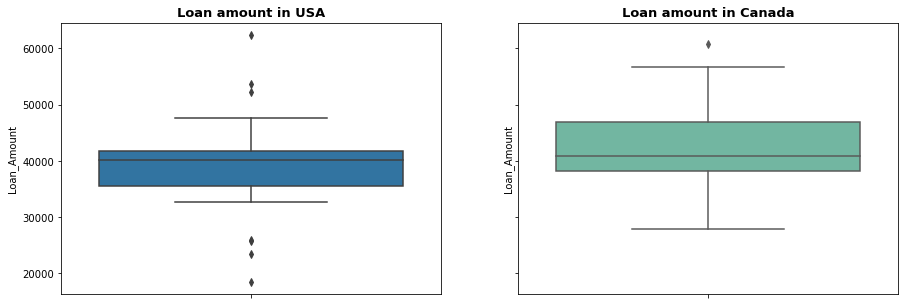

In [45]:
# Separating datasets for USA and Canada

df_usa = df[df['Country'] == 'USA']

df_canada = df[df['Country'] == 'Canada']


fig, axes = plt.subplots(nrows = 1, ncols = 2,sharey= True, figsize = (15,5))


sns.boxplot(data = df_usa, y = 'Loan_Amount',ax = axes[0],palette = 'tab20')
axes[0].set_title('Loan amount in USA',fontsize = 13, fontweight ='bold')


sns.boxplot(data = df_canada, y = 'Loan_Amount', ax = axes[1],palette = 'Set2')
axes[1].set_title('Loan amount in Canada',fontsize =13, fontweight='bold')


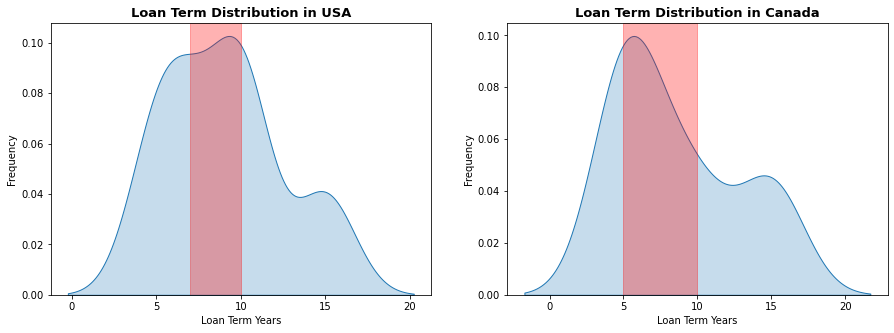

In [46]:
# Let us highlight IQR to understand the distribution in a better way


# Calculating IQR for USA
q1_usa = np.percentile(df_usa['Loan_Term_Years'], 25)
q3_usa = np.percentile(df_usa['Loan_Term_Years'], 75)

# Calculating IQR for Canada
q1_canada = np.percentile(df_canada['Loan_Term_Years'], 25)
q3_canada = np.percentile(df_canada['Loan_Term_Years'], 75)

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize =(15, 5))

# KDE plot for USA
sns.kdeplot(data=df_usa, x= 'Loan_Term_Years', ax= axes[0], fill= True)
axes[0].set_title('Loan Term Distribution in USA', fontsize = 13, fontweight='bold')
axes[0].set_xlabel('Loan Term Years')
axes[0].set_ylabel('Frequency')

axes[0].axvspan(q1_usa, q3_usa, color='red', alpha=0.3)


# KDE plot for Canada
sns.kdeplot(data=df_canada, x = 'Loan_Term_Years', ax = axes[1], fill=True)
axes[1].set_title('Loan Term Distribution in Canada', fontsize = 13, fontweight='bold')
axes[1].set_xlabel('Loan Term Years')
axes[1].set_ylabel('Frequency')

axes[1].axvspan(q1_canada, q3_canada, color='red', alpha=0.3)


plt.show()


Text(0.5, 1.0, 'Cosigner status for Canada')

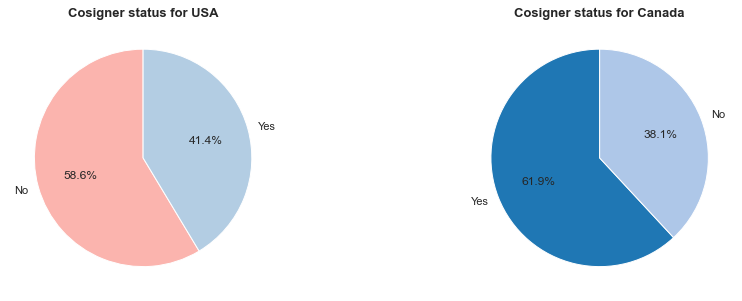

In [47]:
#separating the data set for Cosigner_Present

cosigner_present_USA = df_usa['Cosigner_Present'].value_counts()
cosigner_present_canada = df_canada['Cosigner_Present'].value_counts()


#setting color palletes

colors_usa = sns.color_palette('Pastel1', len(cosigner_present_USA))
colors_canada = sns.color_palette('tab20', len(cosigner_present_canada))
sns.set(style = "whitegrid")

fig, axes = plt.subplots(nrows=1,ncols= 2, figsize = (15,5))


axes[0].pie(cosigner_present_USA, labels = cosigner_present_USA.index , autopct = '%1.1f%%', startangle = 90,
            colors= colors_usa)


axes[0].set_title('Cosigner status for USA',fontsize=13, fontweight='bold')


axes[1].pie(cosigner_present_canada, labels = cosigner_present_canada.index , autopct = '%1.1f%%', startangle = 90,
           colors= colors_canada)


axes[1].set_title('Cosigner status for Canada',fontsize=13, fontweight ='bold')


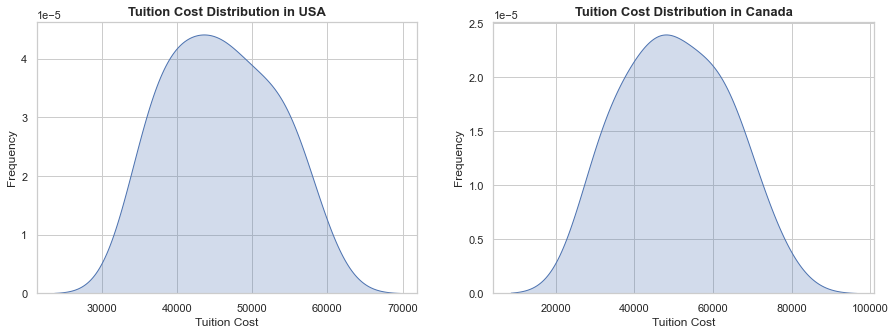

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# KDE plot for USA
sns.kdeplot(data = df_usa, x = 'Tuition_Cost', ax = axes[0], fill= True)
axes[0].set_title('Tuition Cost Distribution in USA',fontsize = 13, fontweight='bold')
axes[0].set_xlabel('Tuition Cost')
axes[0].set_ylabel('Frequency')

# KDE plot for Canada
sns.kdeplot(data = df_canada, x = 'Tuition_Cost', ax= axes[1], fill = True)
axes[1].set_title('Tuition Cost Distribution in Canada',fontsize =13, fontweight='bold')
axes[1].set_xlabel('Tuition Cost')
axes[1].set_ylabel('Frequency')

plt.show()

# Exploratory Data Analysis (EDA)

[Text(0, 0.5, 'Course_Duration_Years'),
 Text(0, 1.5, 'GPA'),
 Text(0, 2.5, 'Loan_Amount'),
 Text(0, 3.5, 'Annual_Income'),
 Text(0, 4.5, 'Loan_Term_Years'),
 Text(0, 5.5, 'Tuition_Cost')]

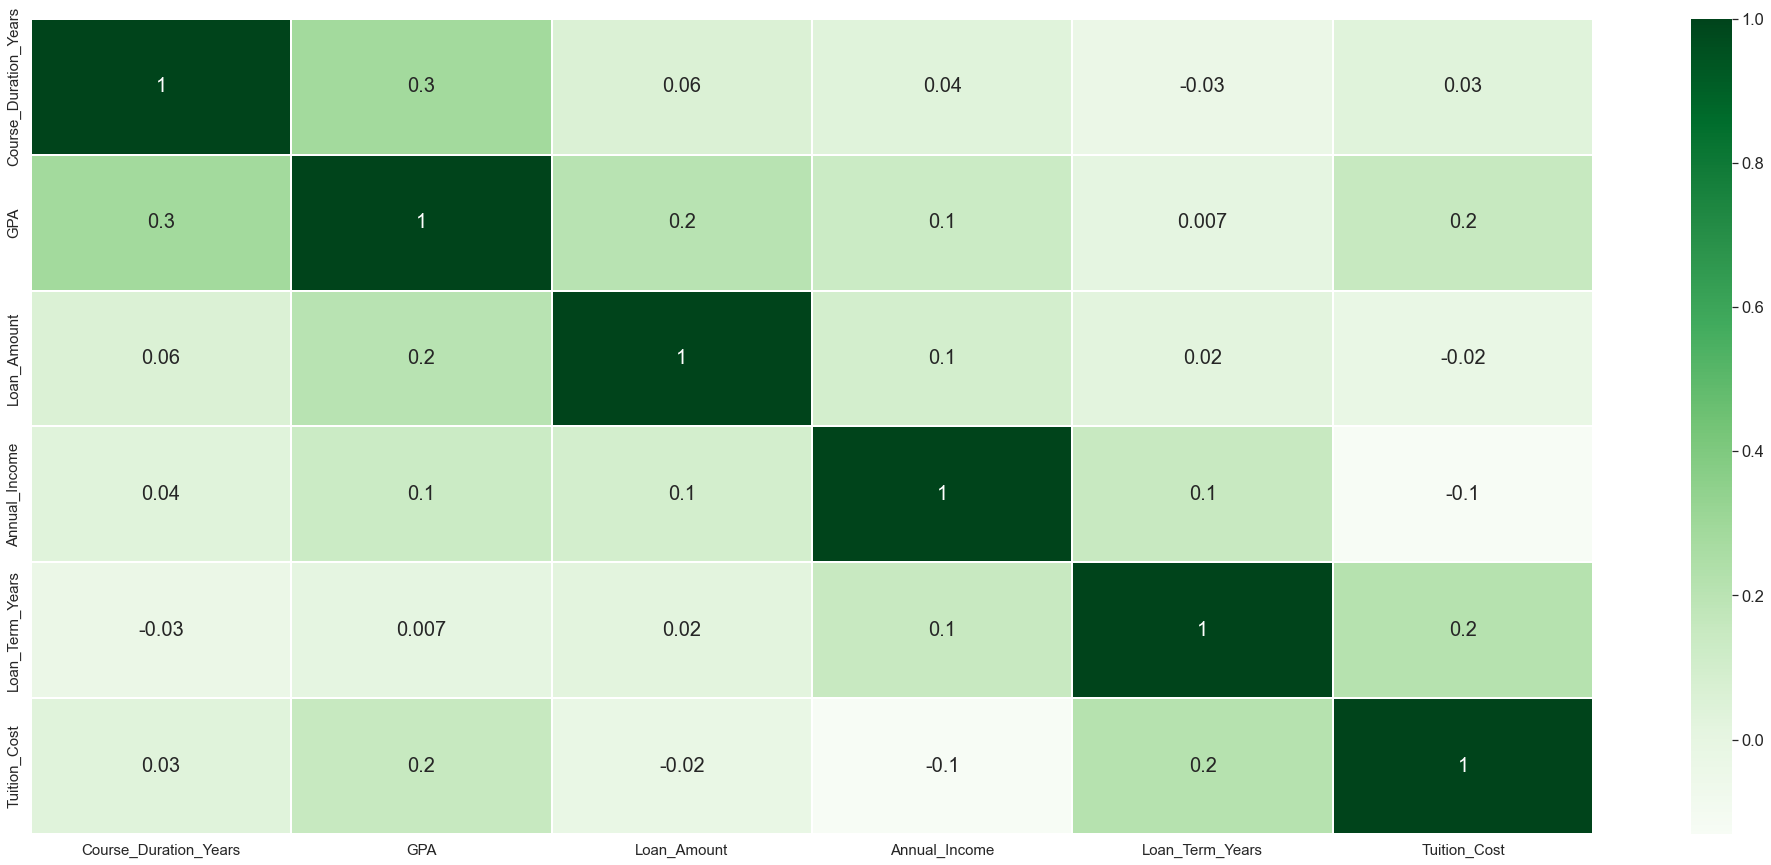

In [49]:
selected_columns = ['Course_Duration_Years','GPA','Loan_Amount','Annual_Income','Loan_Term_Years','Tuition_Cost']

df_selected = df[selected_columns]

fig, ax = plt.subplots(figsize=(35,15)) 
sns.set(font_scale=1.5)

heatmap = sns.heatmap(df_selected.corr(),annot=True,linewidths=.4,fmt='.1g',cmap= "Greens",annot_kws={"size":20})

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=15)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=15)

In [50]:

# Convert date columns to datetime
df['Loan_Disbursement_Date'] = pd.to_datetime(df['Loan_Disbursement_Date'])
df['Graduation_Date'] = pd.to_datetime(df['Graduation_Date'])

# Define the current date
current_date = datetime.now()

# Calculate the expected repayment start date (assuming a 6-month grace period)
df['Repayment_Start_Date'] = df['Graduation_Date'] + pd.DateOffset(months=6)

# Calculate the time remaining until repayment starts
df['Time_Until_Repayment_Start'] = (df['Repayment_Start_Date'] - current_date).dt.days

# Calculate the loan term remaining
df['Loan_Term_Remaining'] = df['Loan_Term_Years'] * 365 - (current_date - df['Loan_Disbursement_Date']).dt.days

# Calculate the Repayment Readiness Index (RRI)
df['Repayment_Readiness_Index'] = df['Time_Until_Repayment_Start']*100.0 / df['Loan_Term_Remaining']



In [51]:
#DTI Debt to income ratio

df['DTI_Ratio'] = df['Loan_Amount']/ df['Annual_Income']

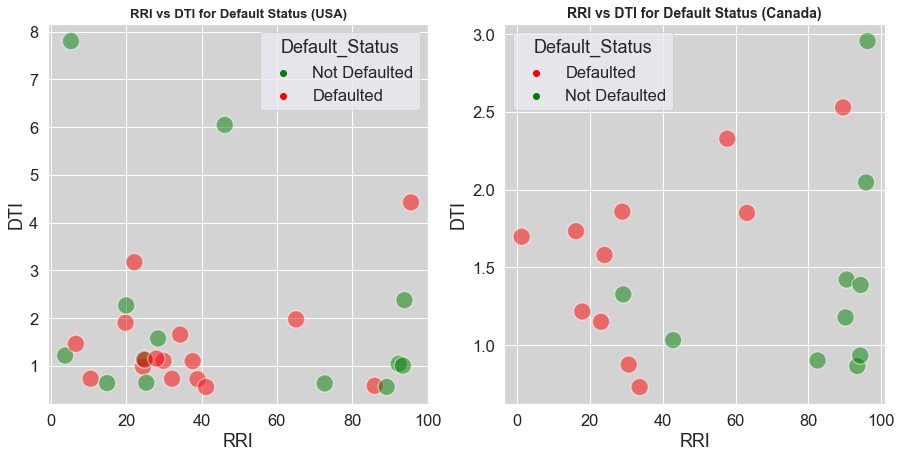

In [52]:
# Separting the datsets

df_usa = df[df['Country'] == 'USA']

df_canada = df[df['Country'] == 'Canada']

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

#setting pallete
custom_palette = {
    
    'Defaulted': 'red',
    'Not Defaulted': 'green'
}

# Scatter plot for USA
sns.scatterplot(ax = axes[0], data = df_usa, x ='Repayment_Readiness_Index', y ='DTI_Ratio', hue ='Default_Status', 
                palette= custom_palette,s= 300, alpha = 0.5)

axes[0].set_title('RRI vs DTI for Default Status (USA)',fontsize=13, fontweight='bold')
axes[0].set_xlabel('RRI')
axes[0].set_ylabel('DTI')
axes[0].set_facecolor('lightgrey')

# Scatter plot for Canada
sns.scatterplot(ax = axes[1], data = df_canada, x ='Repayment_Readiness_Index', y ='DTI_Ratio', hue ='Default_Status', 
                palette= custom_palette, s= 300, alpha = 0.5)

axes[1].set_title('RRI vs DTI for Default Status (Canada)',fontsize=14, fontweight='bold')
axes[1].set_xlabel('RRI')
axes[1].set_ylabel('DTI')
axes[1].set_facecolor('lightgrey')


plt.show()


Text(0.5, 1.0, 'RRI vs Default status in Canada')

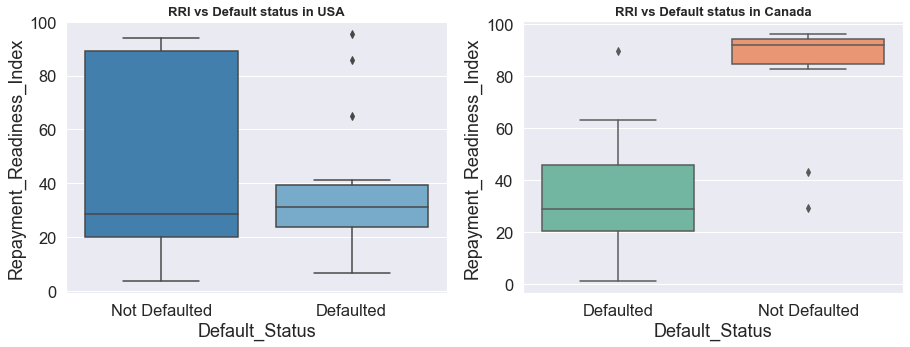

In [53]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))


sns.boxplot(data = df_usa,x = 'Default_Status', y = 'Repayment_Readiness_Index', ax = axes[0], palette= 'tab20c')
axes[0].set_title('RRI vs Default status in USA',fontsize=13, fontweight='bold')


sns.boxplot(data = df_canada, x = 'Default_Status',y = 'Repayment_Readiness_Index',ax = axes[1], palette= 'Set2')
axes[1].set_title('RRI vs Default status in Canada',fontsize=13, fontweight='bold') 


In [54]:
# ANOVA FOR CANADA

from scipy.stats import f_oneway

grouped_data = df_canada.groupby('Default_Status')['Repayment_Readiness_Index'].apply(list)

# Perform ANOVA
anova_result = f_oneway(*grouped_data)
print('F-statistic:', anova_result.statistic)
print('P-value:', anova_result.pvalue)


F-statistic: 17.923292762187387
P-value: 0.00044952200708340406


In [55]:
# ANOVA FOR USA

from scipy.stats import f_oneway

grouped_data = df_usa.groupby('Default_Status')['Repayment_Readiness_Index'].apply(list)

# Perform ANOVA
anova_result = f_oneway(*grouped_data)
print('F-statistic:', anova_result.statistic)
print('P-value:', anova_result.pvalue)

F-statistic: 0.721664173598305
P-value: 0.4030684968112844


Text(0.5, 1.0, 'Repayment status for Canada')

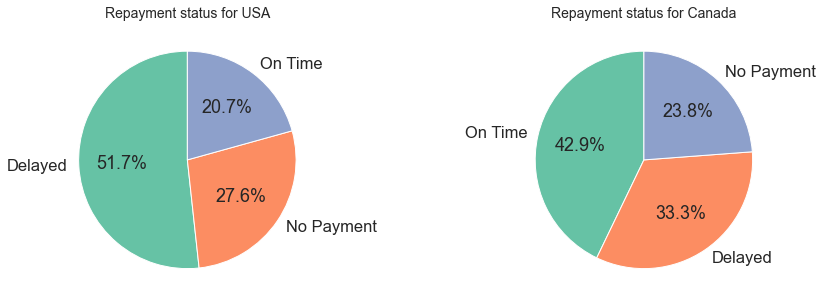

In [56]:
# Separating the dataset

Repayment_status_USA = df_usa['Repayment_Status'].value_counts()
Repayment_status_canada = df_canada['Repayment_Status'].value_counts()

#setting up colors
colors_usa = sns.color_palette('Set2', len(Repayment_status_USA))
colors_canada = sns.color_palette('Set2', len(Repayment_status_canada))


fig, axes = plt.subplots(nrows=1,ncols= 2, figsize = (15,5))

axes[0].pie(Repayment_status_USA, labels = Repayment_status_USA.index , autopct = '%1.1f%%', startangle = 90,colors
    = colors_usa )

axes[0].set_title('Repayment status for USA',fontsize = 14)


axes[1].pie(Repayment_status_canada, labels = Repayment_status_canada.index , autopct = '%1.1f%%', startangle = 90,colors
    = colors_canada )

axes[1].set_title('Repayment status for Canada',fontsize = 14)


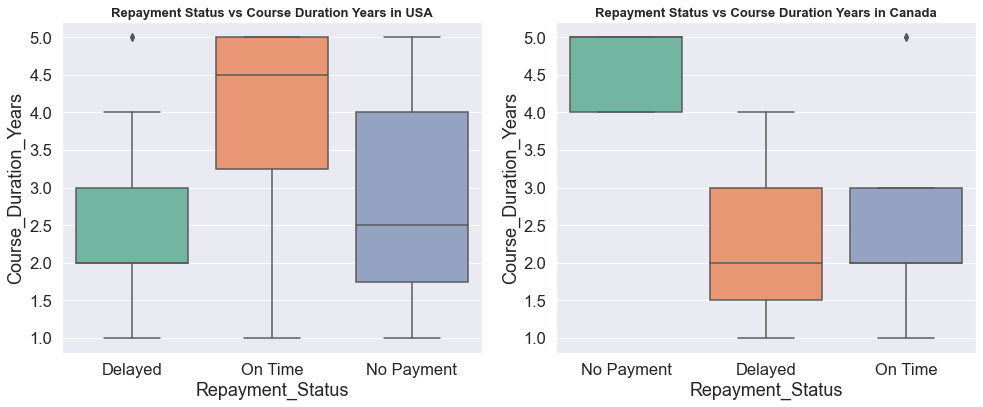

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot for USA
sns.boxplot(data=df_usa, x ='Repayment_Status', y ='Course_Duration_Years', ax = axes[0], palette = 'Set2')
axes[0].set_title('Repayment Status vs Course Duration Years in USA', fontsize=13, fontweight='bold')

# Box plot for Canada
sns.boxplot(data=df_canada,  x ='Repayment_Status', y ='Course_Duration_Years', ax = axes[1], palette = 'Set2')
axes[1].set_title('Repayment Status vs Course Duration Years in Canada', fontsize=13, fontweight='bold')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()


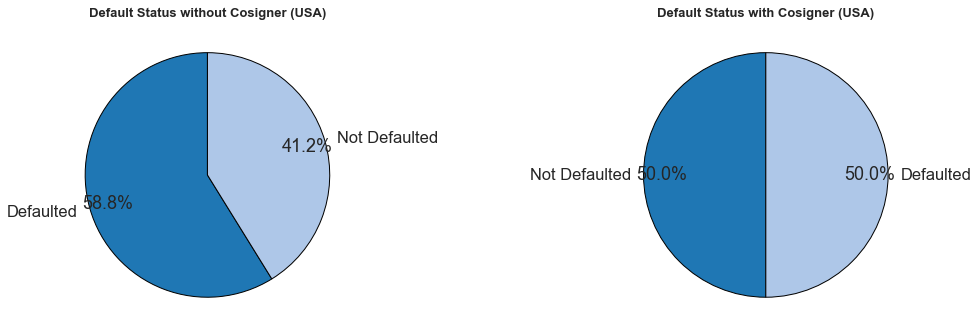

In [58]:
# Filtering data based on cosigner presence
df_usa_cosigner_yes = df_usa[df_usa['Cosigner_Present'] == 'Yes']
df_usa_cosigner_no = df_usa[df_usa['Cosigner_Present'] == 'No']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Setting up palette
colors = sns.color_palette('tab20')

# Plot pie chart for loans without cosigner
df_usa_cosigner_no['Default_Status'].value_counts().plot.pie( ax = axes[0],  autopct='%1.1f%%', startangle=90, 
    colors=colors, wedgeprops={'edgecolor': 'black'}, pctdistance = 0.85)

axes[0].set_title('Default Status without Cosigner (USA)', fontsize=13,  fontweight='bold')

# Removing y-label to avoid overlap
axes[0].set_ylabel('')  



# Plot pie chart for loans with cosigner
df_usa_cosigner_yes['Default_Status'].value_counts().plot.pie( ax = axes[1], autopct ='%1.1f%%', startangle = 90, 
    colors = colors, wedgeprops = {'edgecolor': 'black'}, pctdistance = 0.85 )

axes[1].set_title('Default Status with Cosigner (USA)',fontsize=13, fontweight='bold')

# Removing y-label to avoid overlap
axes[1].set_ylabel('')  

plt.tight_layout()
plt.show()


# Key Insights 


1) Loan Terms: USA students have longer, more varied loan terms; Canada students have shorter, more consistent terms

2) Cosigners: Higher proportion of cosigners in Canada, suggesting cultural or economic differences in lending practices

3) Loan Amounts: Average loan amounts are slightly higher in Canada, likely due to higher tuition costs

4) Loan Term Duration: Canada: 5-7 years, USA: around 10 years

5) RRI: High RRI in Canada correlates with non-defaulted status, Low RRI in USA correlates with defaulted status

6) Payment Timeliness: Higher on-time payments in Canada; more delayed/no payments in the USA

7) Course Duration Impact: In USA longer courses lead to better repayment,however in Canada shorter courses lead to quicker financial stability

8) Cosigner Impact: In the USA, loans with cosigners have better repayment rates compared to those without


# Business Risk Factors

1. RRI: Segment of Students with low RRI in the USA and Canada are at higher risk of default, indicating a need for better financial education and preparedness


2. Cosigners: The absence of cosigners in the USA increases the risk of default While in Canada, cosigners are more common, ensuring their continued use is crucial for maintaining low default rates


3. Rising Tuition Costs: The increasing cost of education in Canada can lead to larger loan amounts, potentially increasing the risk of default.


4. Repayment status: The higher percentage of delayed and no payments in the USA indicates a greater risk of borrowers defaulting on their loans leading losses and bad reputation


# Recommendations

1. Financial Education and Preparedness: Implementing comprehensive financial literacy programs aimed at students with low Repayment Readiness Index (RRI) scores


2. Encouraging Cosigners : Providing incentives such as lower interest rates or reduced fees for loans with cosigners. This can encourage more students to secure cosigners, thereby reducing the risk of default


3. Flexible Repayment Plans: Offering flexible repayment options to help borrowers manage their debt load, especially in the face of rising tuition costs


4. Financial counseling and Support:  Proactive monitoring and early intervention strategies to identify at-risk borrowers could potentially reduce defaults. Offering flexible repayment options, such as income-driven plans and grace period extensions, can make payments more manageable
